# Neural Networks on Fashion MNIST Dataset

## Objective
In this week's exercise, you will:
1. Utilize callback functions to monitor model's performance during training.
2. Experiment with different layer sizes to observe their effects on prediction accuracy and training speed.
3. Implement pixel value normalization to improve network training speed.
4. Construct a multilayer neural network to classify the Fashion MNIST image dataset.

---

## Step 1: Import Libraries
Let's start by importing the necessary libraries.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist


---

## Step 2: Load and Preprocess the Data
We'll load the Fashion MNIST dataset and then normalize the pixel values.


In [2]:
# TODO Load the dataset using the fashion_mnist.load_data() function
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# TODO Normalize the pixel values to be in range 0..1
# each pixel in the Fashion MNIST images is stored as an 8-bit grayscale value: 0 = black, 255 = white
train_images = train_images / 255.0
test_images = test_images / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


---

## Step 3: Visualize the Data
Display some samples from the dataset.


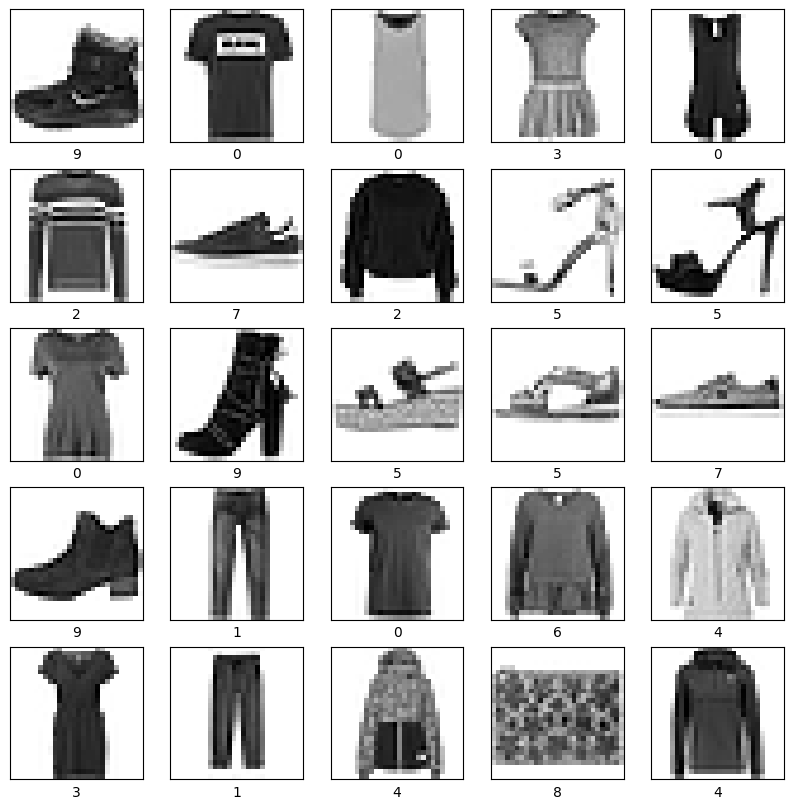

In [3]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(train_labels[i])
plt.show()

---

## Step 4: Define a Callback
Let's define a callback to monitor the model's accuracy during training.
If you're unsure how to do this, (re-)watch this [video](https://www.youtube.com/watch?v=WUzLJZCKNu4) on Callbacks in TensorFlow.

In [4]:
# TODO define a callback that interrupts training after an accuracy of 90% is reached
class AccuracyCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        if logs.get("accuracy") is not None and logs.get("accuracy") >= 0.90:
            print("\nReached 90% accuracy, stopping training.")
            self.model.stop_training = True

accuracy_callback = AccuracyCallback()

---

## Step 5: Build a Neural Network
We will start with a simple neural network and then experiment with different layer sizes.


In [6]:
# TODO build an initial model (hint: you might need to flatten the input in the beginning)
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# TODO compile your model, choose a suitable loss function and metric for measuring training performance
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary
model.summary()
# Optional: research optimizers and try changing the optimizer to one other than the default setting
optimizer=tf.keras.optimizers.SGD()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

---

## Step 6: Train the Model
Train the model using the training data and your callback function.


In [7]:
# TODO Train the model
history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_data=(test_images, test_labels),
    callbacks=[accuracy_callback]
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8248 - loss: 0.4994 - val_accuracy: 0.8509 - val_loss: 0.4166
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8647 - loss: 0.3766 - val_accuracy: 0.8493 - val_loss: 0.4002
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8767 - loss: 0.3384 - val_accuracy: 0.8677 - val_loss: 0.3683
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8859 - loss: 0.3121 - val_accuracy: 0.8638 - val_loss: 0.3736
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8924 - loss: 0.2929 - val_accuracy: 0.8691 - val_loss: 0.3620
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8967 - loss: 0.2786 - val_accuracy: 0.8738 - val_loss: 0.3516
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9033 - loss: 0.2608
Reached 90% accuracy, stopping training.
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9022 - loss: 0.2668 - val_accuracy

---

## Step 7: Evaluate the Model
Evaluate the model using the test data.


In [8]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_accuracy*100:.2f}%")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8712 - loss: 0.3524
Test accuracy: 87.12%


---

## Step 8: Experiment with Layer Sizes
Modify the neural network architecture by changing the layer sizes, and note the effects on training speed and prediction accuracy. You are encouraged to experiment with various configurations.


In [9]:
# Experiment 1: smaller hidden layer
model_small = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_small.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_small = model_small.fit(
    train_images, train_labels,
    epochs=10,
    validation_data=(test_images, test_labels),
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8189 - loss: 0.5214 - val_accuracy: 0.8372 - val_loss: 0.4600
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8616 - loss: 0.3929 - val_accuracy: 0.8426 - val_loss: 0.4378
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8719 - loss: 0.3563 - val_accuracy: 0.8645 - val_loss: 0.3800
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8798 - loss: 0.3330 - val_accuracy: 0.8657 - val_loss: 0.3717
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8857 - loss: 0.3143 - val_accuracy: 0.8715 - val_loss: 0.3649
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8882 - loss: 0.3010 - val_accuracy: 0.8747 - val_loss: 0.3567
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8943 - loss: 0.2885 - val_accuracy: 0.8773 - val_loss: 0.3537
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8981 - loss: 0.2778 - 

In [10]:
# Experiment 2: larger hidden layer
model_large = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_large.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_large = model_large.fit(
    train_images, train_labels,
    epochs=10,
    validation_data=(test_images, test_labels),
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8285 - loss: 0.4832 - val_accuracy: 0.8509 - val_loss: 0.4132
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8662 - loss: 0.3665 - val_accuracy: 0.8514 - val_loss: 0.4124
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8804 - loss: 0.3241 - val_accuracy: 0.8745 - val_loss: 0.3492
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8875 - loss: 0.3037 - val_accuracy: 0.8727 - val_loss: 0.3629
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8941 - loss: 0.2863 - val_accuracy: 0.8725 - val_loss: 0.3505
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8996 - loss: 0.2690 - val_accuracy: 0.8744 - val_loss: 0.3570
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9048 - loss: 0.2571 - val_accuracy: 0.8812 - val_loss: 0.3367
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9073 - loss: 0

In [11]:
# Experiment 3: two hidden layers
model_deeper = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_deeper.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_deeper = model_deeper.fit(
    train_images, train_labels,
    epochs=10,
    validation_data=(test_images, test_labels),
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8236 - loss: 0.4920 - val_accuracy: 0.8512 - val_loss: 0.4137
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8656 - loss: 0.3660 - val_accuracy: 0.8585 - val_loss: 0.4033
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8791 - loss: 0.3301 - val_accuracy: 0.8705 - val_loss: 0.3605
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8880 - loss: 0.3059 - val_accuracy: 0.8691 - val_loss: 0.3620
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8919 - loss: 0.2905 - val_accuracy: 0.8613 - val_loss: 0.3867
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8986 - loss: 0.2746 - val_accuracy: 0.8742 - val_loss: 0.3374
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9018 - loss: 0.2641 - val_accuracy: 0.8770 - val_loss: 0.3527
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9046 - loss: 0.2537 -

In [12]:
small_loss, small_acc = model_small.evaluate(test_images, test_labels, verbose=0)
large_loss, large_acc = model_large.evaluate(test_images, test_labels, verbose=0)
deeper_loss, deeper_acc = model_deeper.evaluate(test_images, test_labels, verbose=0)

print(f"Small model accuracy:  {small_acc*100:.2f}%")
print(f"Large model accuracy:  {large_acc*100:.2f}%")
print(f"Deeper model accuracy: {deeper_acc*100:.2f}%")

Small model accuracy:  88.06%
Large model accuracy:  88.65%
Deeper model accuracy: 88.62%


In [13]:
configs = [32, 64, 128, 256]

for units in configs:
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(units, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(train_images, train_labels, epochs=5, verbose=0)
    loss, acc = model.evaluate(test_images, test_labels, verbose=0)
    print(f"Units: {units}, Test Accuracy: {acc*100:.2f}%")

Units: 32, Test Accuracy: 86.35%
Units: 64, Test Accuracy: 87.00%
Units: 128, Test Accuracy: 87.25%
Units: 256, Test Accuracy: 87.01%
